# Ice Core Power Spectra
Applications of spectral analysis techniques to synthetic data sets to assess how sampling methods, data handling, and statistical choices affect interpretability of ice core data sets in the frequency domain <br/>
<br/>
Originally coded by Rhys-Jasper León <br/>
Last updated 2026 April 23

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.fft import fft, fftfreq
from utils import *

## STEP 1: Create Data
We want to create a synthetic time series that is on the same order as other deep ice cores so it can be used to effectively understand the impacts of different sampling methods on ice cores and the inherent depth-age relationship. <br/>
<br/>
For this example, we will use the WAIS Divide core's chronology to set up our synthetic data. The synthetic time series used in the following example will be purely random with no added signals and the same length as WDC at 1-year resolution. A random white-spectrum dataset is valuable for this analysis because with real data, certain factors which may obscure the true signal in the data must be considered, including post-depositional processes, sampling methods, and data processing. Further, overlapping and discontinuous signals present in the record may complicate the ability to discern artefacts of data manipulation from true signals in the resulting spectra. Because the data used in this analysis is a pure white-spectrum time series, the complications of post-depositional processes and sampling methods have been removed, and the lack of periodic signals in the data allows the effects of data manipulation to be observed directly.

Text(0, 0.5, 'Depth (m)')

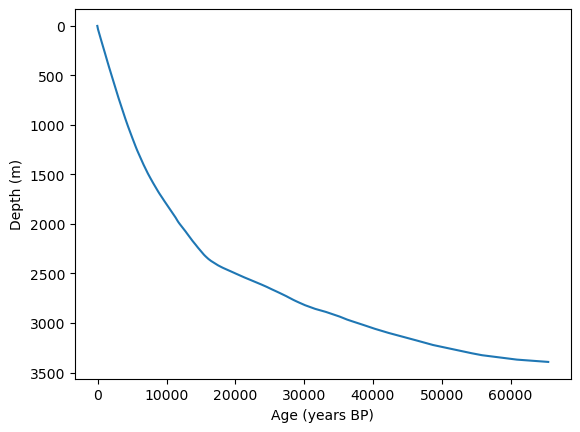

In [2]:
# read in WDC depth-age scale
wdc_data = pd.read_csv('WD2014_Chronology.tab', sep='\t', header=52)
wdc_depth = wdc_data['Depth ice/snow [m]']
wdc_age = wdc_data['Cal age [ka BP] (ice age)'] # part of the issue is that this chronology is already on even-time
wdc_age = wdc_age * 1000  # convert to years BP

# wdc_data.head()
plt.plot(wdc_age, wdc_depth)
plt.gca().invert_yaxis()
plt.xlabel('Age (years BP)')
plt.ylabel('Depth (m)')

Text(0.5, 0, 'Time (years)')

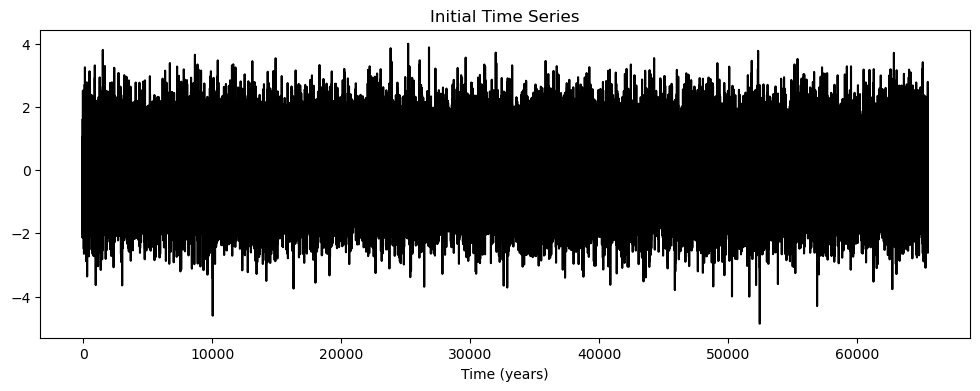

In [3]:
# specify length of time series (make sure it matches time length of wdc age model)
xlen = int(wdc_age.max())  # length of time series (years)

# create even time axis
x = np.arange(int(wdc_age.min()), xlen + 1)  # time (yr)
# create random noise
y = np.random.normal(0, 1, len(x)) # normal distibution, mean 0, std 1

# plot initial time series
fig, ax = plt.subplots(figsize=(12, 4))
plt.plot(x, y, label='Raw Synthetic Data', color='black')
plt.title('Initial Time Series')
# plt.xlim(0, 200)  # limit x-axis for better visibility
plt.xlabel('Time (years)')

## STEP 2: Compare fft vs. Welch
We want to examine different spectral methods to see if the choice of spectral method has an impact on the interpretability of our results. Fourier transforms can be used to recover signals from periodic components. To perform Fourier analysis, I used the scipy.fft package, which uses a fast algorithm known as the Fast Fourier Transform (FFT) to compute the 1-dimensional discrete Fourier transform of the time series. The Welch method of spectral analysis is composed of multiple periodograms averaged together for overlapping segments to estimate the power spectral density (PSD). The signal processing package scipy.signal includes a Welch method function, which was used for this analysis. <br/>

> **Note:** For the FFT, I took only the positive frequencies when applying `fftfreq`, which is done with: `[:len(x)//2]`

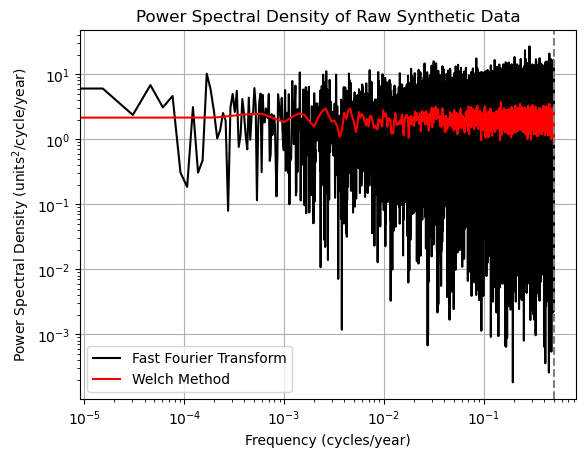

In [4]:
res = np.mean(np.diff(x))
fs = 1 / res  # sampling frequency (samples/yr)

freqw, psdw = welch(y, fs=fs, nperseg=5000) # frequency units: cycles/yr, output value: psd
fourier = fft(y) # output value: amplitude
freqf = fftfreq(len(x), res)[:len(x)//2] # frequency units: cycles/yr
psdf = 2 * np.abs(fourier)**2 / (len(x) * fs) # convert amplitude to psd


plt.figure()
# plot fft of initial time series
plt.plot(freqf, psdf[:len(x)//2], label='Fast Fourier Transform', color='black')
# plot welch method initial time series
plt.loglog(freqw, psdw, label='Welch Method', color='red')
plt.axvline(x=1/res/2, color='gray', linestyle='--', label=f'')
plt.xlabel('Frequency (cycles/year)')
plt.ylabel(r'Power Spectral Density (units$^2$/cycle/year)')
plt.title('Power Spectral Density of Raw Synthetic Data')
plt.grid()
plt.legend()

As we can see above, choosing a large segment length for the Welch method greatly smooths the PSD estimate compared to the FFT. Both the FFT and Welch method do a good job of capturing the same patterns. The Welch method’s biggest advantage is the reduction of noise in the PSD estimate but the trade-off is that it results in a much lower frequency resolution compared to the FFT. Playing with different segment lengths and different sampling resolutions (below in STEP 3), you would find that the default segment length has a large smoothing effect on higher resolution time series (e.g., raw, 10yr) with a decreasing smoothing effect as the resolution decreases (e.g., 100yr, 500yr). If the segment length is set to be proportional to the length of the input time series so as to maintain consistent degrees of freedom, then the smoothing effect is more similar across sampling frequencies, and the spectra overlay each other similarly to the spectra from the FFT. <br/>
<br/>
We will explore different sampling methods next, but this notebook will not go into depth about changing the segment length for the Welch method, and for now, the degrees of freedom are irrelevant since we will not be performing significance testing on the white-spectrum data set. If you introduce known signals into your synthetic data and want to test the significance of the peaks in the resulting power spectrum, it would be wise to select the appropriate segment length that would yield the desired value for degrees of freedom.

## STEP 3: Sampling Methods

### Discrete Averaging
**Complete discrete sampling** in an ice core is when a chunk of ice is homogenized into a single point. To model this process, all data points in a given time chunk of the synthetic data are averaged to create a single point to represent that time interval, with no repeated information between points of the downsampled time series.

C:\Users\rice\AppData\Local\Temp\ipykernel_5248\590412368.py:18: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 131, using nperseg = 131
  freqw, psdw = welch(y_ds, fs=fs) # frequency units: cycles/yr, output value: psd


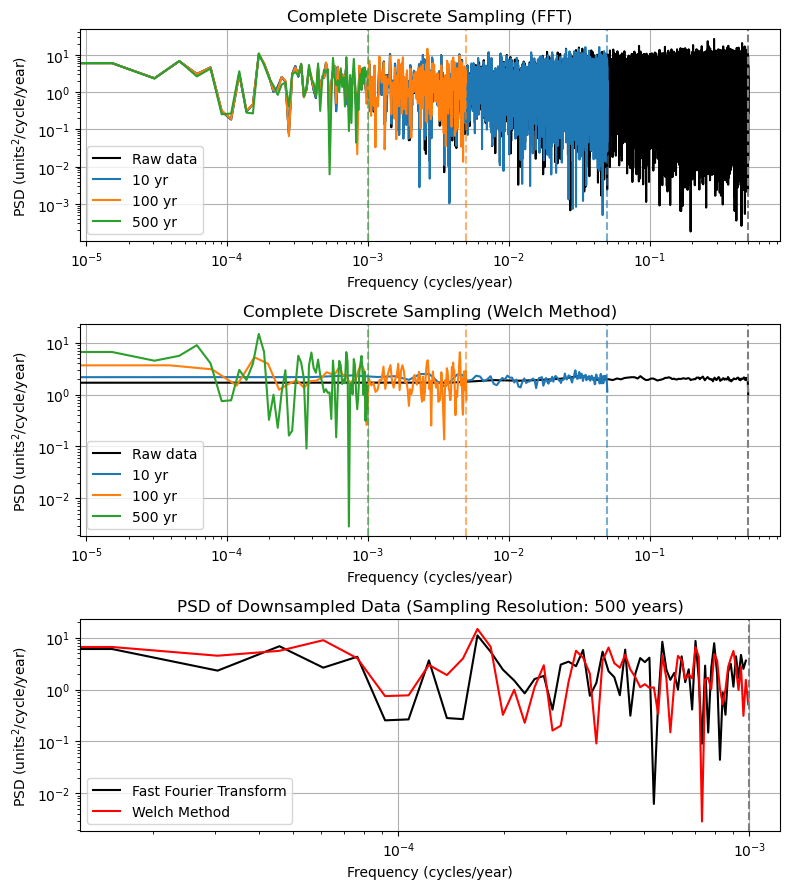

In [5]:
# complete discrete sampling
sampling_resolution = [10, 100, 500] # years

fig, ax = plt.subplots(3, 1, figsize=(8, 9))
fourier = fft(y) # output value: amplitude
freqf = fftfreq(len(x), 1)[:len(x)//2] # frequency units: cycles/yr
psdf = 2 * np.abs(fourier)**2 / (len(x) * 1) # convert amplitude to psd
ax[0].loglog(freqf, psdf[:len(x)//2], label='Raw data', color='black') # plot welch of raw data
ax[0].axvline(x=1/2, color='gray', linestyle='--', label=f'')
freqy, psdy = welch(y, fs=1)
ax[1].loglog(freqy, psdy, label='Raw data', color='black') # plot welch of raw data
ax[1].axvline(x=1/2, color='gray', linestyle='--', label=f'')

for i, res in enumerate(sampling_resolution):
    x_ds, y_ds = discrete_avg(x, y, res, method='full')
    fs = 1 / res  # sampling frequency (samples/yr)
    
    freqw, psdw = welch(y_ds, fs=fs) # frequency units: cycles/yr, output value: psd
    fourier = fft(y_ds) # output value: amplitude
    freqf = fftfreq(len(x_ds), res)[:len(x_ds)//2] # frequency units: cycles/yr
    psdf = 2 * np.abs(fourier)**2 / (len(x_ds) * fs) # convert amplitude to psd

    color = f'C{i}'

    # plot resulting spectra
    ax[0].loglog(freqf, psdf[:len(x_ds)//2], label=f'{res} yr', color=color) # plot fft
    ax[0].axvline(x=1/res/2, color=color, linestyle='--', alpha=0.6)
    ax[0].set_xlabel('Frequency (cycles/year)')
    ax[0].set_ylabel(r'PSD (units$^2$/cycle/year)')
    ax[0].set_title(f'Complete Discrete Sampling (FFT)')
    ax[0].grid()
    ax[0].legend()

    ax[1].loglog(freqw, psdw, label=f'{res} yr', color=color) # plot welch
    ax[1].axvline(x=1/res/2, color=color, linestyle='--', alpha=0.6)
    ax[1].set_xlabel('Frequency (cycles/year)')
    ax[1].set_ylabel(r'PSD (units$^2$/cycle/year)')
    ax[1].set_title(f'Complete Discrete Sampling (Welch Method)')
    ax[1].grid()
    ax[1].legend()

    if res == sampling_resolution[-1]:
        ax[2].plot(freqf, psdf[:len(x_ds)//2], label='Fast Fourier Transform', color='black') # plot fft
        ax[2].loglog(freqw, psdw, label='Welch Method', color='red') # plot welch
        ax[2].axvline(x=1/res/2, color='gray', linestyle='--', label=f'')
        ax[2].set_xlabel('Frequency (cycles/year)')
        ax[2].set_ylabel(r'PSD (units$^2$/cycle/year)')
        ax[2].set_title(f'PSD of Downsampled Data (Sampling Resolution: {res} years)')
        ax[2].grid()
        ax[2].legend()

plt.tight_layout()

With **incomplete discrete sampling**, we are selecting a single point to represent a given chunk of "missing" data using linear interpolation to estimate "missing" points. Since our original synthetic data has no gaps and is at a higher resolution than our desired sampling resolutions, the function just selects the known point at the center of the interval without needing to estimate between points.

C:\Users\rice\AppData\Local\Temp\ipykernel_5248\2135134458.py:20: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 131, using nperseg = 131
  freqw, psdw = welch(y_int, fs=fs) # frequency units: cycles/yr, output value: psd


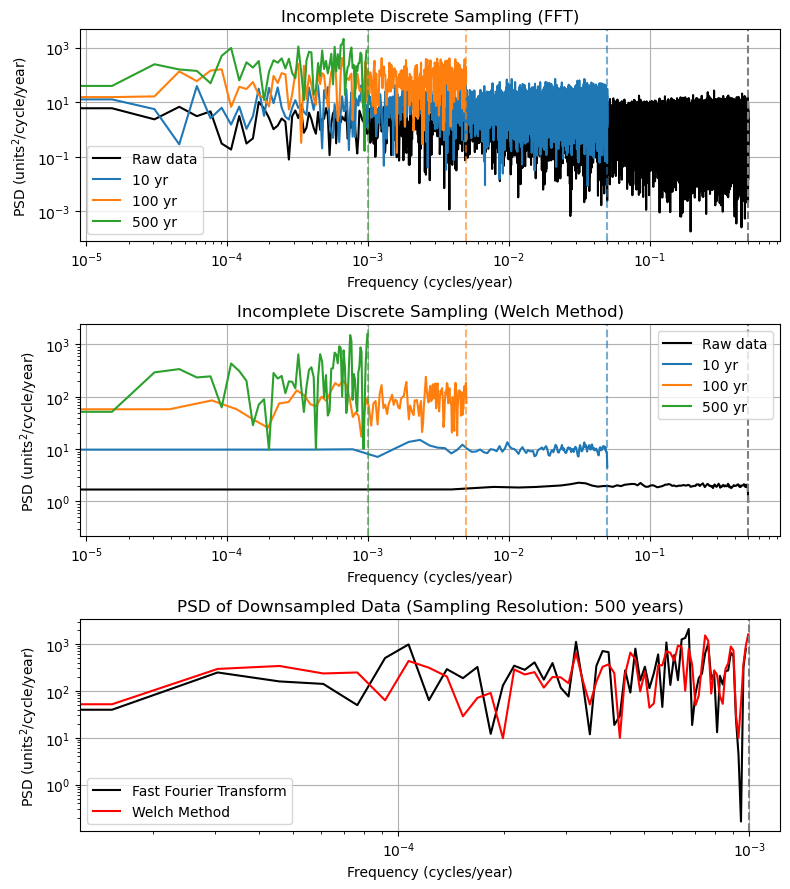

In [6]:
# incomplete discrete sampling (interpolation)
sampling_resolution = [10, 100, 500] # years

fig, ax = plt.subplots(3, 1, figsize=(8, 9))
fourier = fft(y) # output value: amplitude
freqf = fftfreq(len(x), 1)[:len(x)//2] # frequency units: cycles/yr
psdf = 2 * np.abs(fourier)**2 / (len(x) * 1) # convert amplitude to psd
ax[0].loglog(freqf, psdf[:len(x)//2], label='Raw data', color='black') # plot welch of raw data
ax[0].axvline(x=1/2, color='gray', linestyle='--', label=f'')
freqy, psdy = welch(y, fs=1)
ax[1].loglog(freqy, psdy, label='Raw data', color='black') # plot welch of raw data
ax[1].axvline(x=1/2, color='gray', linestyle='--', label=f'')


for i, res in enumerate(sampling_resolution):
    x_ds, y_ds = discrete_avg(x, y, res, method='full')
    y_int = np.interp(x_ds, x, y) # interpolate to downsample
    fs = 1 / res  # sampling frequency (samples/yr)
    
    freqw, psdw = welch(y_int, fs=fs) # frequency units: cycles/yr, output value: psd
    fourier = fft(y_int) # output value: amplitude
    freqf = fftfreq(len(x_ds), res)[:len(x_ds)//2] # frequency units: cycles/yr
    psdf = 2 * np.abs(fourier)**2 / (len(x_ds) * fs) # convert amplitude to psd

    color = f'C{i}'

    # plot resulting spectra
    ax[0].loglog(freqf, psdf[:len(x_ds)//2], label=f'{res} yr', color=color) # plot fft
    ax[0].axvline(x=1/res/2, color=color, linestyle='--', alpha=0.6)
    ax[0].set_xlabel('Frequency (cycles/year)')
    ax[0].set_ylabel(r'PSD (units$^2$/cycle/year)')
    ax[0].set_title(f'Incomplete Discrete Sampling (FFT)')
    ax[0].grid()
    ax[0].legend()

    ax[1].loglog(freqw, psdw, label=f'{res} yr', color=color) # plot welch
    ax[1].axvline(x=1/res/2, color=color, linestyle='--', alpha=0.6)
    ax[1].set_xlabel('Frequency (cycles/year)')
    ax[1].set_ylabel(r'PSD (units$^2$/cycle/year)')
    ax[1].set_title(f'Incomplete Discrete Sampling (Welch Method)')
    ax[1].grid()
    ax[1].legend()

    if res == sampling_resolution[-1]:
        ax[2].plot(freqf, psdf[:len(x_ds)//2], label='Fast Fourier Transform', color='black') # plot fft
        ax[2].loglog(freqw, psdw, label='Welch Method', color='red') # plot welch
        ax[2].axvline(x=1/res/2, color='gray', linestyle='--', label=f'')
        ax[2].set_xlabel('Frequency (cycles/year)')
        ax[2].set_ylabel(r'PSD (units$^2$/cycle/year)')
        ax[2].set_title(f'PSD of Downsampled Data (Sampling Resolution: {res} years)')
        ax[2].grid()
        ax[2].legend()

plt.tight_layout()

We can also compare the **complete discrete sampling** to the **incomplete discrete sampling** directly by creating a ratio between the two:

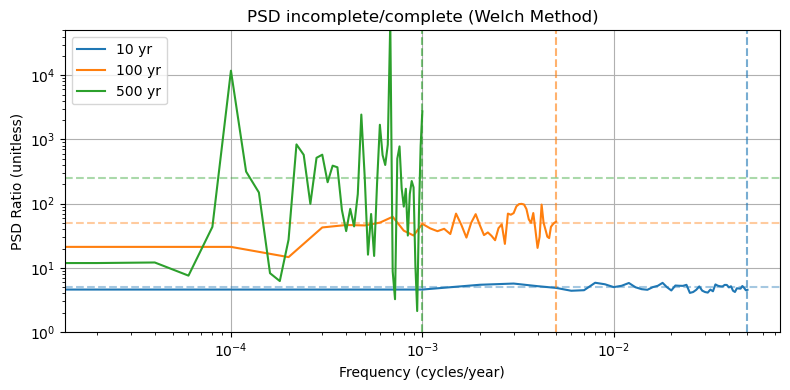

In [7]:
# compare complete vs incomplete discrete sampling
sampling_resolution = [10, 100, 500] # years

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

for i, res in enumerate(sampling_resolution):
    x_ds, y_ds = discrete_avg(x, y, res, method='full')
    y_int = np.interp(x_ds, x, y) # interpolate to downsample 
    fs = 1 / res  # sampling frequency (samples/yr)
    
    freqw, psdw = welch(y_ds, fs=fs, nperseg=100) # frequency units: cycles/yr, output value: psd
    fourier = fft(y_ds) # output value: amplitude
    freqf = fftfreq(len(x_ds), res)[:len(x_ds)//2] # frequency units: cycles/yr
    psdf = 2 * np.abs(fourier)**2 / (len(x_ds) * fs) # convert amplitude to psd

    freqwi, psdwi = welch(y_int, fs=fs, nperseg=100) # frequency units: cycles/yr, output value: psd
    fourieri = fft(y_int) # output value: amplitude
    freqfi = fftfreq(len(x_ds), res)[:len(x_ds)//2] # frequency units: cycles/yr
    psdfi = 2 * np.abs(fourieri)**2 / (len(x_ds) * fs) # convert amplitude to psd

    color = f'C{i}'

    # plot resulting spectra
    plt.loglog(freqw, psdwi/psdw, label=f'{res} yr', color=color) # plot welch ratio
    plt.axvline(x=fs/2, color=color, linestyle='--', alpha=0.6)
    plt.axhline(y=res/2, color=color, linestyle='--', alpha=0.4)  # reference line
    plt.xlabel('Frequency (cycles/year)')
    plt.ylabel('PSD Ratio (unitless)')
    plt.title(f'PSD incomplete/complete (Welch Method)')
    plt.grid()
    plt.legend()
    plt.ylim([1e0, 5e4]);

plt.tight_layout()

#### To summarize our findings for discrete sampling:
For the **complete discrete sampling**, both spectral methods maintain the same PSD as the spectrum of the original raw data across varying sampling frequencies. With the FFT, the shapes of the spectra are incredibly similar up until the highest resolved frequency for each respective sampling frequency, called the Nyquist frequency (vertical dotted lines), is reached. With the Welch method, the spectra for each sampling resolution seem to have roughly the same average PSD up until each respective Nyquist frequency is reached, with additional differences in amounts of noise in the estimate (* see note above regarding segment length). <br/>
<br/>

For the **incomplete discrete sampling**, we observe very similar results as with the **complete discrete sampling**, but with the added complication that the **incomplete discrete sampling** raises the PSD estimate as the sampling frequency of the input series decreases. When comparing the ratio of **incomplete discrete sampling** to **complete discrete sampling**, we observe that downsampling by **incomplete discrete sampling** raises PSD by a factor of *half of the sampling resolution* (horizontal dotted lines) relative to the spectra of the data handled with **complete discrete sampling**.

### Moving Averages
Continuous sampling of ice cores is essentially the same process as **complete discrete sampling** but at much higher resolution. A continuous flow analysis (CFA) system continuously melts ice, resulting in mixing in records. For this study, we will be using moving averages as an analogue for continuous sampling. <br/>
<br/>

We will be comparing two different window shapes: **boxcar** and **gaussian**. A **boxcar** window gives equal weight to all data points, so it is a rectangular window with abrupt edges. A **gaussian** window weights data on a gaussian distribution for a given window of data, so the window shape has tapered edges. The functions used to perform the moving averages are found in `utils.py`. <br/>
<br/>

The moving averages apply discrete convolution of the designated window over the entire time series, which keeps the altered data at the same resolution as the original synthetic time series (1 year). As such, the resulting spectra for all of the altered data sets share the same Nyquist frequency (grey dashed vertical line). The altered data shown below compare the effects of different window sizes of the same shape with each other. To assess the impact of the different moving averages on the resulting PSD estimate, I found the frequency at which the PSD reaches 95% of its low-frequency (millennial-scale) PSD when going from high frequency to low frequency (colored dashed vertical lines).


In [8]:
boxcar3 = boxcar(y, 3)
boxcar5 = boxcar(y, 5)
boxcar20 = boxcar(y, 21)
boxcar100 = boxcar(y, 101)

gaussian3 = gaussian(y, 3)
gaussian5 = gaussian(y, 5)
gaussian20 = gaussian(y, 21)
gaussian100 = gaussian(y, 101)

For Boxcar MA (5), 95% of own low-freq PSD reached at: 7.3143 yr
For Boxcar MA (20), 95% of own low-freq PSD reached at: 32.0000 yr
For Boxcar MA (100), 95% of own low-freq PSD reached at: 128.0000 yr


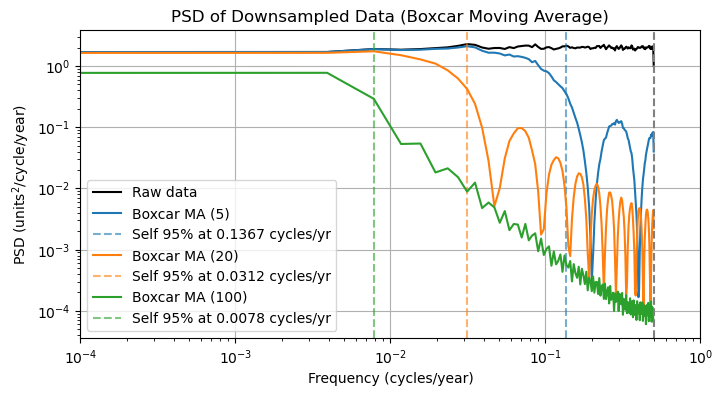

In [9]:
# boxcar moving average
fig, ax = plt.subplots(figsize=(8, 4))

freqy, psdy = welch(y, fs=1)
ax.loglog(freqy, psdy, label='Raw data', color='black') # plot welch of raw data

# produce spectra of smoothed data
for i, (data, label) in enumerate(zip([boxcar5, boxcar20, boxcar100], ['Boxcar MA (5)', 'Boxcar MA (20)', 'Boxcar MA (100)'])):
    res = np.mean(np.diff(x)) # downsampling resolution (years)
    fs = 1 / res  # sampling frequency (samples/yr)
    color = f'C{i}'

    freqw, psdw = welch(data, fs=fs) # frequency units: cycles/yr, output value: psd

    ax.loglog(freqw, psdw, color=color, label=label) # plot welch

    # find frequency where smoothed PSD is 95% of its own low-freq PSD
    freq_95_self = find_95_self(freqw, psdw)
    if freq_95_self:
        ax.axvline(freq_95_self, linestyle='--', color=color, alpha=0.6, label=f'Self 95% at {freq_95_self:.4f} cycles/yr')
        print(f'For {label}, 95% of own low-freq PSD reached at: {1/freq_95_self:.4f} yr')
    
ax.axvline(x=1/res/2, color='gray', linestyle='--', label=f'')
ax.set_xlabel('Frequency (cycles/year)')
ax.set_ylabel(r'PSD (units$^2$/cycle/year)')
ax.set_title(f'PSD of Downsampled Data (Boxcar Moving Average)')
ax.grid()
ax.legend()
ax.set_xlim(1e-4, 1e0);

When examining the data altered by the **boxcar** moving average, all of the resulting spectra demonstrate a large drop-off in PSD as they approach the Nyquist frequency. The decrease in PSD is larger for larger window sizes, and increasing the window size increases the number of resonance humps. This spectral ringing is a manifestation of the Gibbs phenomenon, which occurs because the Fourier series does not converge uniformly at discontinuities, so the terms in the Fourier series representing the higher-frequency components do not cancel out appropriately.

For Gaussian MA (5), 95% of own low-freq PSD reached at: 3.8209 yr
For Gaussian MA (20), 95% of own low-freq PSD reached at: 17.0667 yr
For Gaussian MA (100), 95% of own low-freq PSD reached at: 85.3333 yr


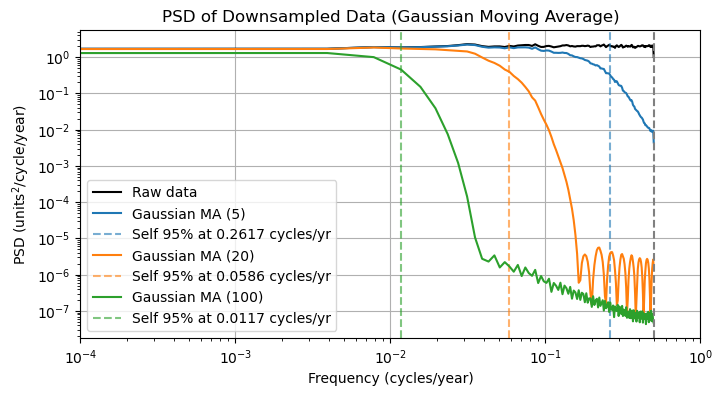

In [10]:
# gaussian moving average
fig, ax = plt.subplots(figsize=(8, 4))

freqy, psdy = welch(y, fs=1)
ax.loglog(freqy, psdy, label='Raw data', color='black') # plot welch of raw data

# produce spectra of smoothed data
for i, (data, label) in enumerate(zip([gaussian5, gaussian20, gaussian100], ['Gaussian MA (5)', 'Gaussian MA (20)', 'Gaussian MA (100)'])):
    res = np.mean(np.diff(x)) # downsampling resolution (years)
    fs = 1 / res  # sampling frequency (samples/yr)
    color = f'C{i}'

    freqw, psdw = welch(data, fs=fs) # frequency units: cycles/yr, output value: psd

    ax.loglog(freqw, psdw, color=color, label=label) # plot welch

    # find frequency where smoothed PSD is 95% of its own low-freq PSD
    freq_95_self = find_95_self(freqw, psdw)
    if freq_95_self:
        ax.axvline(freq_95_self, linestyle='--', color=color, alpha=0.6, label=f'Self 95% at {freq_95_self:.4f} cycles/yr')
        print(f'For {label}, 95% of own low-freq PSD reached at: {1/freq_95_self:.4f} yr')

ax.axvline(x=1/res/2, color='gray', linestyle='--', label=f'')
ax.set_xlabel('Frequency (cycles/year)')
ax.set_ylabel(r'PSD (units$^2$/cycle/year)')
ax.set_title(f'PSD of Downsampled Data (Gaussian Moving Average)')
ax.grid()
ax.legend()
ax.set_xlim(1e-4, 1e0);

The PSD reduction is generally greater for the **gaussian** moving average than the **boxcar** moving average for each corresponding window size. Additionally, the reduction in PSD happens more suddenly for the **gaussian** moving average than for the **boxcar** moving average. Further, the spectra with the **gaussian** moving average will have fewer resonance humps than with the **boxcar** moving average, and those resonance humps begin closer to the Nyquist frequency than they do for the **boxcar** moving average. The **boxcar** windowing creates a more severe ringing effect than the **gaussian** windowing because the **boxcar** window has abrupt edges leading to sharp discontinuities. The tapered **gaussian** window helps to suppress the spectral leakage and its associated ringing, so the ringing effect is less severe than for the **boxcar** window. When considering the 95% vertical lines, the spectrum of the data smoothed by a **gaussian** moving average reaches 95% of its low-frequency PSD in a period that is much shorter than for the data smoothed by a **boxcar** moving average of the same corresponding window length, meaning fewer of the high frequencies are impacted by the **gaussian** moving average. <br/>
<br/>

In real life, CFA is most closely related to a moving average that also downsamples the data, though it is not completely analogous. Some parts of a CFA system may demonstrate more of a **boxcar** averaging (e.g., sampling and the flow of melt water into different melt lines), while other parts might emulate more of **gaussian** averaging (e.g., meltwater moving through the debubbler and nebulizer). Cavity ring-down spectroscopy (CRDS) might be better described by an **exponential** moving average with more weight given to recent points, which was not tested in this analysis. <br/>

#### Some additional considerations:
Similar features to those observed above also occur in spectral estimate of real ice core data. Diffusion of water isotopes occurs post-depositionally in the ice sheet, which can be observed in the reddening of real data from discretely sampled ice cores. Further reddening of the spectrum can be tied to mixing occurring in the analytical system and may not be part of the true signal, meaning that the shapes of the spectra from ice core data using complete discrete sampling vs. a CFA system could appear different due to the additional mixing across the CFA system. This additional mixing limits our ability to make direct comparisons between spectra of ice cores sampled with different methods. 

#### Further limitations
A CFA system is not completely analogous with the moving averages from this analysis because the overlap of information between two adjacent points is constant in these moving average functions, whereas mixing within a CFA system does not occur at a constant rate (e.g., variations in melt rate or flow rate). With an ice core, the time domain is also not evenly spaced due to the thinning of layers with depth, so mixing in a CFA system, even if at a constant rate, would not be mixing the same amount of time between two adjacent points.

## STEP 4: Depth-Age Relationship
Layer compression occurs with depth in an ice sheet, so depth and age have a non-linear relationship with each other. Then, because ice cores are typically sampled at even depth intervals, the inherent depth-age relationship becomes integrated into resulting time series. We want to create a synthetic dataset that mimics how an ice core may typically be sampled to investigate how this inherent relationship distorts the resulting power spectrum. To do this, we will convert our original data set evenly spaced in time to be on an evenly-spaced depth axis. We will create an evenly-spaced depth axis matching the depths of WDC and then interpolate the original y-data onto the new depth axis, which is our sampling analogue. To then perform spectral analysis, we will convert this back to a time series using three different resolutions: 1) the **lowest** time resolution between points, or the time resolution at bottom of core; 2) the **average** time resolution across the entire core; and 3) the average resolution of just the **Holocene** section.

In [11]:
dy = 0.5 # sampling interval (m)
wdc_even_depth = np.arange(int(wdc_depth.min()) + dy, wdc_depth.max(), dy) # cut off the ends to ensure no extrapolation
wdc_new_age = np.interp(wdc_even_depth, wdc_depth, wdc_age)
y_to_depth = np.interp(wdc_new_age, x, y) # data values connected to times on even depth scale (m)

Lowest resolution: 86.43333333331975 years
Average resolution: 9.648770050067222 years
Holocene average resolution: 2.970494019278743 years


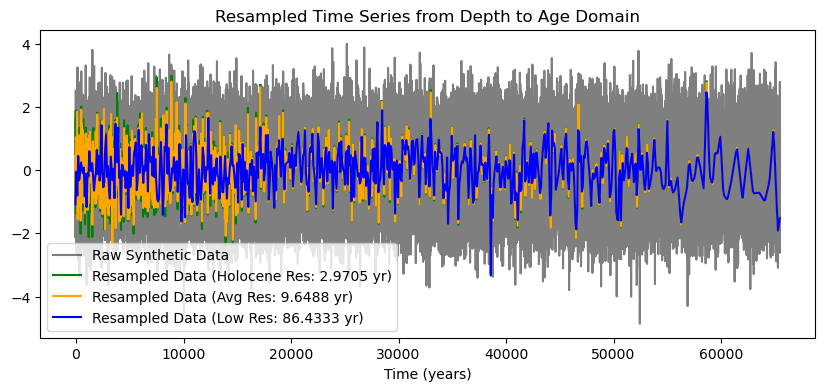

In [12]:
# low_res = np.max(np.diff(wdc_new_age))  # lowest resolution in years
low_res = np.diff(wdc_new_age)[-1]  # resolution between last two points in years
avg_res = np.mean(np.diff(wdc_new_age))  # average resolution in years
holocene_res = np.mean(np.diff(wdc_new_age[wdc_new_age <= 11700]))  # Holocene average resolution in years
print(f'Lowest resolution: {low_res} years')
print(f'Average resolution: {avg_res} years')
print(f'Holocene average resolution: {holocene_res} years')

# resample to specified resolutions
low_age, low_y = depth_to_age(wdc_new_age, y_to_depth, low_res, wdc_depth, wdc_age)
avg_age, avg_y = depth_to_age(wdc_new_age, y_to_depth, avg_res, wdc_depth, wdc_age)
holocene_age, holocene_y = depth_to_age(wdc_new_age, y_to_depth, holocene_res, wdc_depth, wdc_age)

fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(x, y, label='Raw Synthetic Data', color='black', alpha=0.5)
plt.plot(holocene_age, holocene_y, label=f'Resampled Data (Holocene Res: {holocene_res:.4f} yr)', color='green')
plt.plot(avg_age, avg_y, label=f'Resampled Data (Avg Res: {avg_res:.4f} yr)', color='orange')
plt.plot(low_age, low_y, label=f'Resampled Data (Low Res: {low_res:.4f} yr)', color='blue')
plt.title('Resampled Time Series from Depth to Age Domain')
plt.xlabel('Time (years)')
plt.legend()

(0.0001, 1.0)

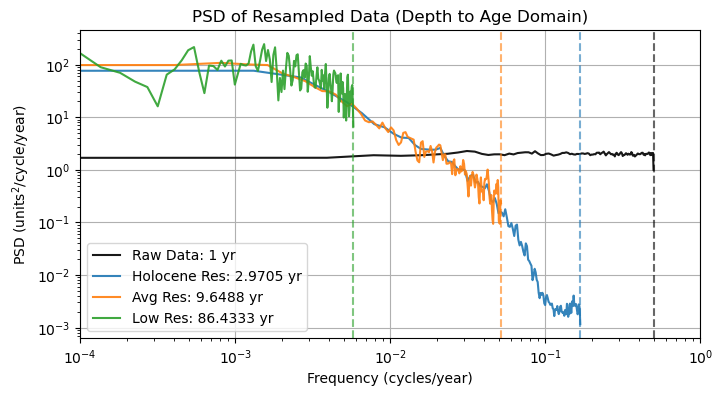

In [13]:
# produce spectra of resampled data
fig, ax = plt.subplots(figsize=(8, 4))

for i, (data, age, label) in enumerate(zip([y, holocene_y, avg_y, low_y], [x, holocene_age, avg_age, low_age], 
                           ['Raw Data: 1 yr', f'Holocene Res: {holocene_res:.4f} yr', f'Avg Res: {avg_res:.4f} yr', f'Low Res: {low_res:.4f} yr'])):
    res = np.mean(np.diff(age)) # downsampling resolution (years)
    fs = 1 / res  # sampling frequency (samples/yr)
    if i == 0:
        color = 'black'
    else:
        color = f'C{i-1}'

    freqw, psdw = welch(data, fs=fs) # frequency units: cycles/yr, output value: psd

    ax.loglog(freqw, psdw, color=color, alpha=0.9, label=label) # plot welch
    ax.axvline(x=1/res/2, color=color, alpha=0.6, linestyle='--', label=f'')

ax.set_xlabel('Frequency (cycles/year)')
ax.set_ylabel(r'PSD (units$^2$/cycle/year)')
ax.set_title(f'PSD of Resampled Data (Depth to Age Domain)')
ax.grid()
ax.legend()
ax.set_xlim(1e-4, 1e0)

Across all of the altered spectra, the PSD decreases drastically at high frequencies compared to the spectrum of the raw data and increases at low frequencies. The increase in PSD at the low frequencies is marginally greater as the resolution of the time series decreases. Going from low frequency to high frequency, the Holocene resolution spectrum starts with high power then begins decreasing at a frequency of around 1/500 years, crosses the spectrum of the raw data around 1/50 years, and then seems to flatten out from 1/10 years until its Nyquist frequency. At frequencies higher than ~1/500, the average resolution spectrum seems to match the Holocene resolution spectrum in terms of shape, with some additional noise. <br/>

#### Findings:
Resampling using the **lowest** resolution allows us to resolve the lowest frequencies the best without oversampling other parts of the core, but it has the potential to introduce distortions to the spectra at higher frequencies, which could be mistaken for real features. Resampling using the **average** resolution across the entire core strikes a good balance and is ideally not undersampling or oversampling too much of the top and bottom of the core respectively. This allows the lower frequencies to be well-resolved without losing too much information from higher frequencies like the **lowest** resolution does. Resampling using the average resolution from only the **Holocene** portion of the core gives us the ability to resolve the highest frequencies and allows for analysis of shorter timescales, but with the trade-off of oversampling much of the core, so the spectral estimates at the low frequencies must be interpreted keeping that in mind. <br/>

#### Additional considerations for comparisons:
If you want to compare the spectra of multiple ice core records to each other, an additional factor to consider beyond the ones covered above is the accumulation rate. A higher accumulation rate means layers that are deposited are thicker than at locations with a lower accumulation rate, so higher frequencies can be resolved and the distortion at the low frequencies will be slightly lessened by comparison. Additionally, as thinning occurs down the core, those thicker layers contribute to a higher resolution of the signal along the depth axis. This means that when converting from the sampled depth-proxy record to a time series, less over- and undersampling will occur across the core compared to one from a location with a lower accumulation rate. <br/>
<br/>
If you want to compare the spectra from different kinds of paleoclimate proxy records, it is also important to consider that different archives have different inherent resolutions (i.e., depth-age relationship) and distinct formation processes that can induce distortions to the original signal (e.g., in-situ mixing, post-depositional diffusion, etc.).


## Testing some additional conditions

`utils.py` also contains some additional wrapper functions to make these analyses easier:
- `run_analyses` will run all the above tests when provided with a data set and any ice core chronology
- `spectral_tests` will help you to generate a synthetic time series and then run the above tests when provided with any ice core chronology

In [14]:
# you can check that the run_analyses function produces the same results using the above x/y and WDC age model or test a different synthetic time series and/or ice core chronology
%matplotlib inline
# run_analyses(x, y, wdc_depth, wdc_age, interval=[10, 100, 500], window=[3, 5, 21, 101])

You entered: 2 added signals
Sine wave 1 has a period of 67.0 and amplitude of 0.4
Sine wave 2 has a period of 203.0 and amplitude of 1.5
We have now collected all known signals to add to your red-spectrum data.
You chose a lag-1 autocorrelation of 0.89.
Your red-spectrum time series with added signals has been created.
Each spectrum produced using the Welch method will use 9 segments.
~~~ Comparing FFT vs. Welch Method for Spectral Analysis ~~~


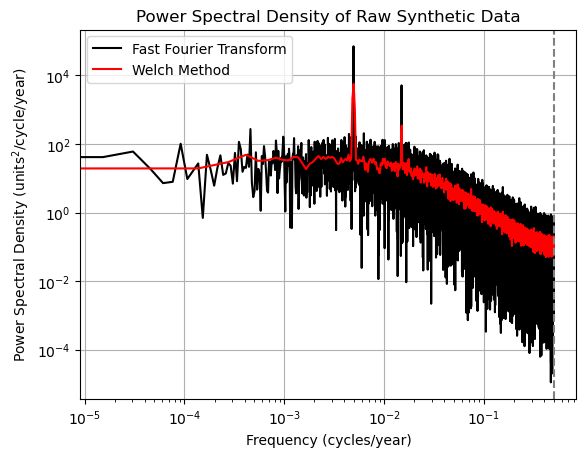

~~~ Comparing Effects of Complete vs. Incomplete Discrete Sampling on Resulting Spectra ~~~


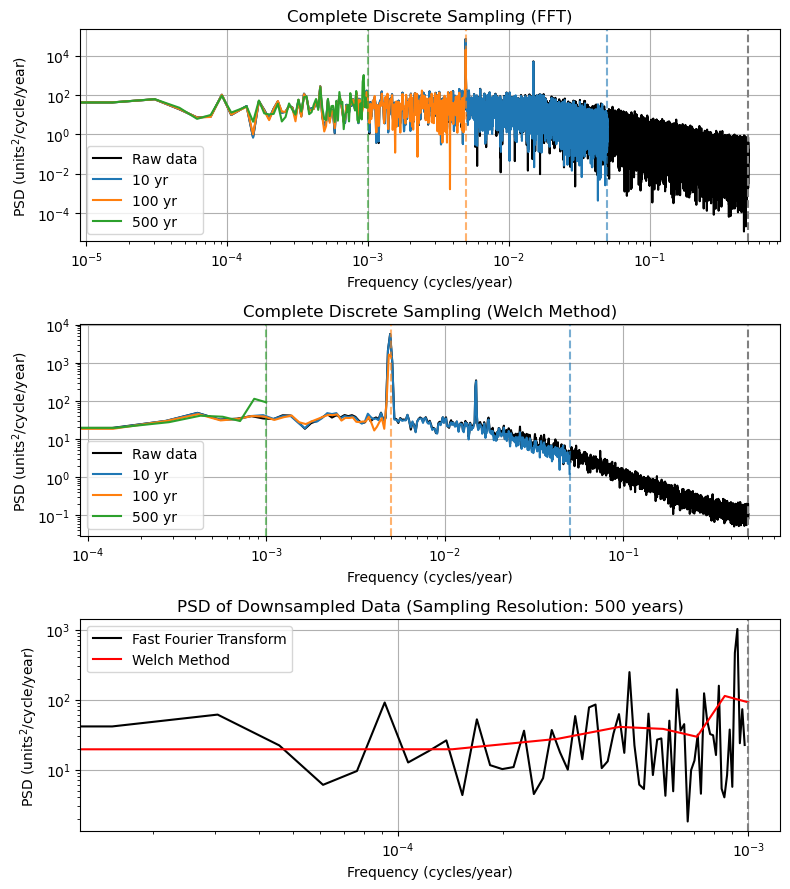

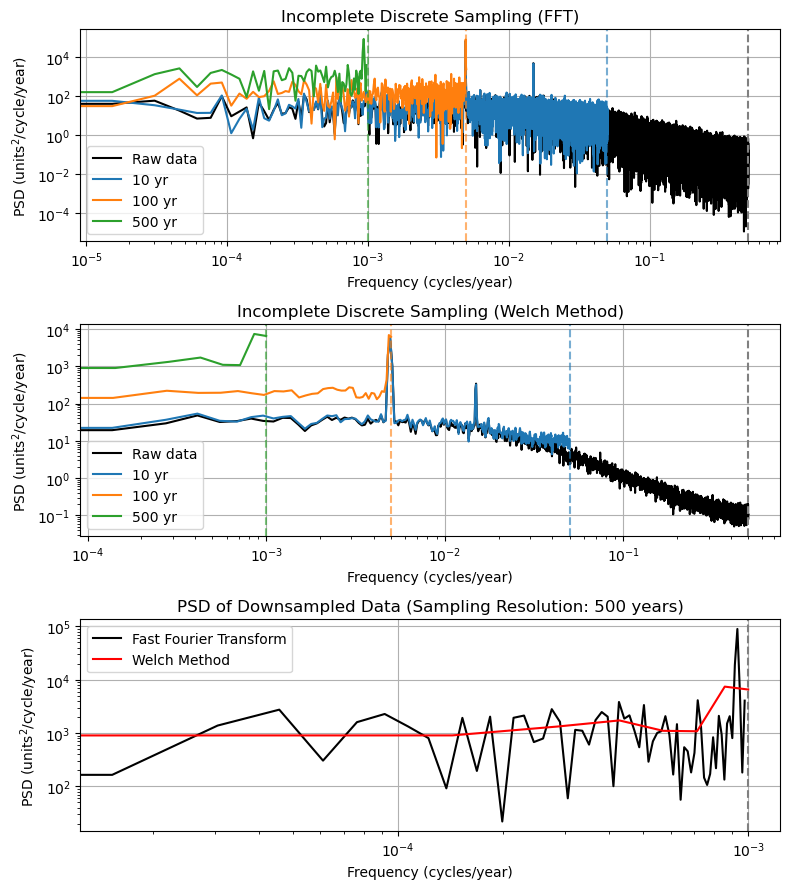

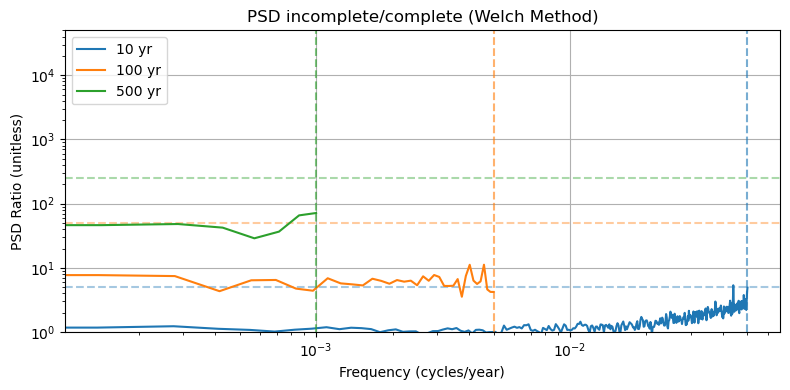

~~~ Comparing Effects of Different Smoothing Windows on Resulting Spectra ~~~
For Boxcar (5), 95% of own low-freq PSD reached at: 56.8828 yr
For Gaussian (5), 95% of own low-freq PSD reached at: 56.8828 yr
For Boxcar (21), 95% of own low-freq PSD reached at: 66.7798 yr
For Gaussian (21), 95% of own low-freq PSD reached at: 56.8672 yr
For Boxcar (101), 95% of own low-freq PSD reached at: 196.4865 yr
For Gaussian (101), 95% of own low-freq PSD reached at: 196.4865 yr


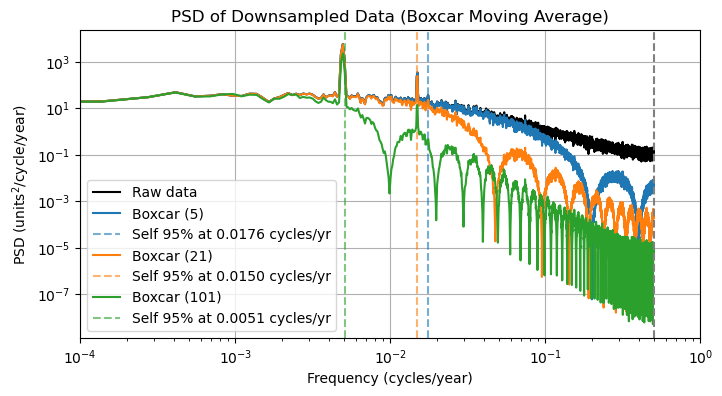

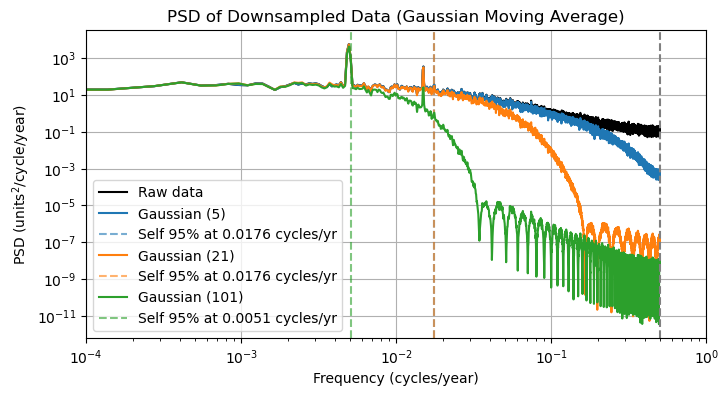

~~~ Comparing Effects of Resampling from Depth to Age Domain at Different Resolutions ~~~
Creating new resampled time series:
Lowest resolution: 86.43333333331975 years
Average resolution: 9.648770050067222 years
Holocene average resolution: 2.970494019278743 years


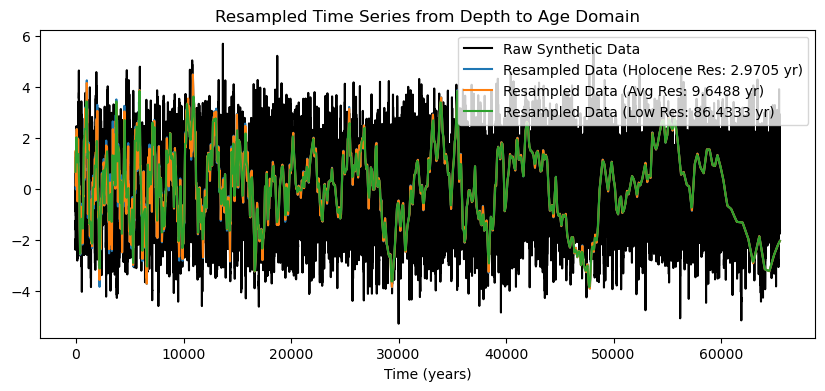

Producing spectra of resampled data:


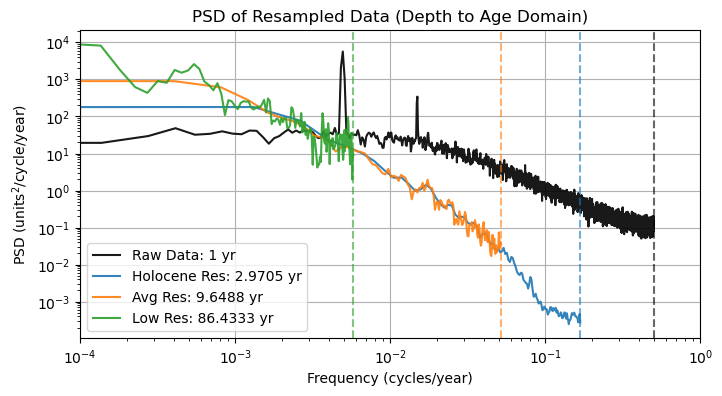

In [15]:
# try some different synthetic data sets (you can save the synthetic time series created when calling this function)
x1, y1 = spectral_tests(wdc_depth, wdc_age, interval=[10, 100, 500], window=[5, 21, 101], data='red', segments='number')